In [2]:
import pandas as pd
import warnings
warnings.simplefilter('ignore')

In [3]:
df = pd.read_csv('emailspam.csv')

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.to_csv('emailspam.csv',index=False)

# Text cleaning

In [7]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [8]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91756\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91756\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
import nltk
import os

# Create local nltk_data folder inside your project
nltk_data_path = os.path.join(os.getcwd(), 'nltk_data')

nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('punkt', download_dir=nltk_data_path)

print("Downloaded to:", nltk_data_path)

Downloaded to: e:\Fraud-Sms-Email-Detection\Email_spam\nltk_data


[nltk_data] Downloading package stopwords to e:\Fraud-Sms-Email-
[nltk_data]     Detection\Email_spam\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to e:\Fraud-Sms-Email-
[nltk_data]     Detection\Email_spam\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
import nltk
import os

nltk_data_path = os.path.join(os.getcwd(), 'nltk_data')
nltk.data.path.append(nltk_data_path)

In [11]:
from nltk.corpus import stopwords

print(stopwords.words('english')[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [12]:

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()
corpus = []
for i in range(len(df)):
    rp = re.sub('[^a-zA-A]', " ", df['message'][i])
    rp = rp.lower()
    rp = rp.split()
    rp = [ps.stem(word) for word in rp if not word in set (stopwords.words('english'))]
    rp = ' '.join(rp)
    corpus.append(rp)
    
corpus   

['jurong point crazi avail bugi n great world la e buffet ine got amor wat',
 'k lar oke wif u oni',
 'ree entri wkli comp win final tkt st ay ext receiv entri question std txt rate appli',
 'dun say earli hor c alreadi say',
 'ah think goe usf live around though',
 'ree sg ey darl week word back like fun still b ok x std chg send rcv',
 'ven brother like speak hey treat like aid patent',
 'per request ell ell ru innaminungint urungu ettam set callertun aller ress copi friend allertun',
 'valu network custom select receivea prize reward claim call laim code alid hour',
 'ad mobil month entitl pdate latest colour mobil camera ree obil pdate',
 'gonna home soon want talk stuff anymor tonight k cri enough today',
 'chanc win rom pound txt send ost p day day sand appli epli info',
 'ou week membership rize ackpot xt word www dbuk net',
 'search right word thank breather promis wont take help grant fulfil promis ou wonder bless time',
 '',
 'obil ovi lub use credit click link next txt messa

# Vectorization 

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X = cv.fit_transform(corpus).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 6354))

In [14]:
y = pd.get_dummies(df['label'],drop_first = True)

In [15]:
y

,spam
0,False
1,False
2,True
3,False
4,False
...,...
5567,True
5568,False
5569,False
5570,False


# Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 0)

In [17]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3900, 6354))

# modeling

********************
********************
train_accuracy 0.9930769230769231
test_accuracy 0.9754784688995215
********************
[[1423   28]
 [  13  208]]
********************


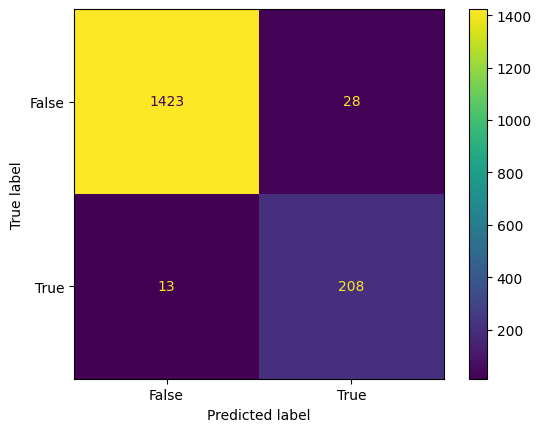

In [18]:
# modeling
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

print('*'*20)

# prediction
test_prediction = model.predict(X_test)
train_prediction = model.predict(X_train)

# evaluation
print('*'*20)

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('train_accuracy', accuracy_score(y_train, train_prediction))
print('test_accuracy', accuracy_score(y_test, test_prediction))

print('*'*20)

print(confusion_matrix(y_test, test_prediction))

print('*'*20)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

# cross validation score

In [19]:
from sklearn.model_selection import cross_val_score
score= cross_val_score(model,X,y,cv=5)

print(score)
score.mean()

[0.97757848 0.97757848 0.97755835 0.98025135 0.97486535]


np.float64(0.9775663991111898)

# classification report

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test,test_prediction))

              precision    recall  f1-score   support

       False       0.99      0.98      0.99      1451
        True       0.88      0.94      0.91       221

    accuracy                           0.98      1672
   macro avg       0.94      0.96      0.95      1672
weighted avg       0.98      0.98      0.98      1672



# logistic regression 

********************
********************
train_accuracy 0.9935897435897436
test_accuracy 0.9820574162679426
********************
[[1449    2]
 [  28  193]]
********************


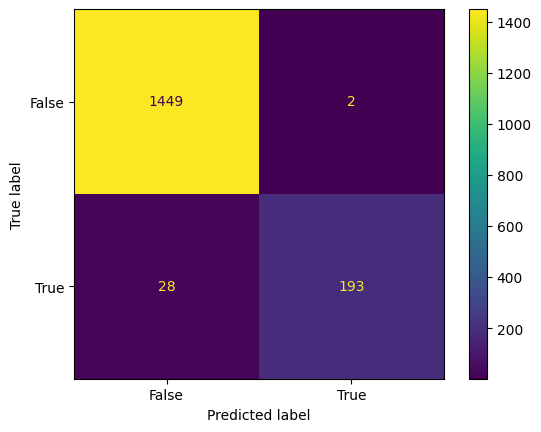

********************
[0.98116592 0.9793722  0.97755835 0.98025135 0.97755835]
0.97918123193598


In [21]:
# modeling
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train, y_train)

print('*'*20)

# prediction
test_prediction = lr.predict(X_test)
train_prediction = lr.predict(X_train)

# evaluation
print('*'*20)

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('train_accuracy', accuracy_score(y_train, train_prediction))
print('test_accuracy', accuracy_score(y_test, test_prediction))

print('*'*20)

print(confusion_matrix(y_test, test_prediction))

print('*'*20)

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

print('*'*20)

# cross validation
from sklearn.model_selection import cross_val_score

score = cross_val_score(lr, X, y, cv=5)

print(score)
print(score.mean())

In [22]:
from sklearn.model_selection import cross_val_score
score= cross_val_score(model,X,y,cv=5)

print(score)
score.mean()

[0.97757848 0.97757848 0.97755835 0.98025135 0.97486535]


np.float64(0.9775663991111898)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test,test_prediction))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      1451
        True       0.99      0.87      0.93       221

    accuracy                           0.98      1672
   macro avg       0.99      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672



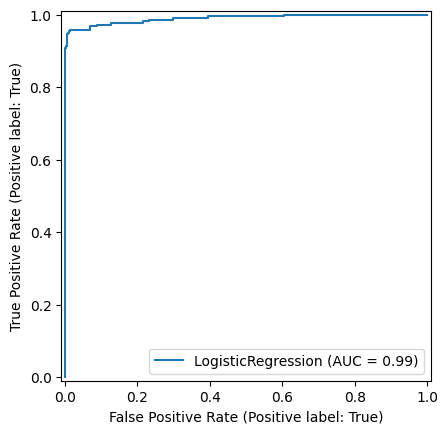

In [24]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.show()

# decision tree classification

********************
********************
train_accuracy 0.9987179487179487
test_accuracy 0.9748803827751196
********************
[0.967713   0.97309417 0.97486535 0.96140036 0.96768402]
0.9689513811176145
********************
[[1435   16]
 [  26  195]]
********************


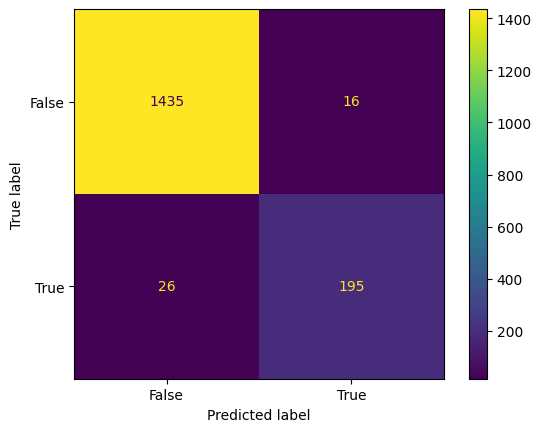

In [25]:
# modeling
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

print('*'*20)

# prediction
test_prediction = dtc.predict(X_test)
train_prediction = dtc.predict(X_train)

# evaluation
print('*'*20)

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('train_accuracy', accuracy_score(y_train, train_prediction))
print('test_accuracy', accuracy_score(y_test, test_prediction))

print('*'*20)

# cross validation
from sklearn.model_selection import cross_val_score

score = cross_val_score(dtc, X, y, cv=5)
print(score)
print(score.mean())

print('*'*20)

# confusion matrix
print(confusion_matrix(y_test, test_prediction))

print('*'*20)

# plot confusion matrix (NEW METHOD)
ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)
plt.show()

In [26]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(dtc,X,y,cv=5)
print(score)
score.mean()

[0.96681614 0.97309417 0.96947935 0.96229803 0.96768402]


np.float64(0.9678743428520823)

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test,test_prediction))

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      1451
        True       0.92      0.88      0.90       221

    accuracy                           0.97      1672
   macro avg       0.95      0.94      0.94      1672
weighted avg       0.97      0.97      0.97      1672



# KNN Classifier

0.909688995215311
0.9228205128205128
********************
0.9136752783569893
********************
[[1450    1]
 [ 150   71]]
********************


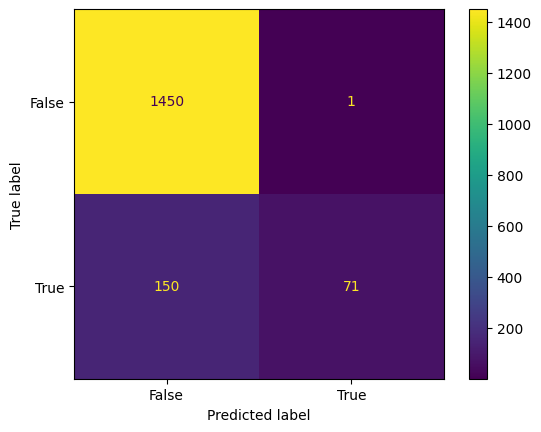

********************
              precision    recall  f1-score   support

       False       0.91      1.00      0.95      1451
        True       0.99      0.32      0.48       221

    accuracy                           0.91      1672
   macro avg       0.95      0.66      0.72      1672
weighted avg       0.92      0.91      0.89      1672



In [28]:
from sklearn.neighbors import KNeighborsClassifier

# model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# prediction
train_prediction = knn_model.predict(X_train)
test_prediction = knn_model.predict(X_test)

# evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print(accuracy_score(y_test, test_prediction))
print(accuracy_score(y_train, train_prediction))

print('*'*20)

# cross validation
from sklearn.model_selection import cross_val_score
score = cross_val_score(knn_model, X, y, cv=5)
print(score.mean())

print('*'*20)

# confusion matrix
print(confusion_matrix(y_test, test_prediction))

print('*'*20)

# plot confusion matrix
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)
plt.show()

print('*'*20)

# classification report
print(classification_report(y_test, test_prediction))

# random forest technique

In [29]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier(random_state=42,bootstrap=False)
rfc.fit(X_train,y_train)

# prediction
train_prediction= rfc.predict(X_train)
test_prediction= rfc.predict(X_test)

# evaluation
from sklearn.metrics import accuracy_score
print('train accuracy:',accuracy_score(y_test,test_prediction))
print('test accuracy:',accuracy_score(y_train,train_prediction))

# cross validation score
from sklearn.model_selection import cross_val_score
score=cross_val_score(rfc,X,y,cv=5)
print(score)

score.mean()

train accuracy: 0.9760765550239234
test accuracy: 0.9987179487179487
[0.98116592 0.97757848 0.97486535 0.96947935 0.97666068]


np.float64(0.9759499561230488)

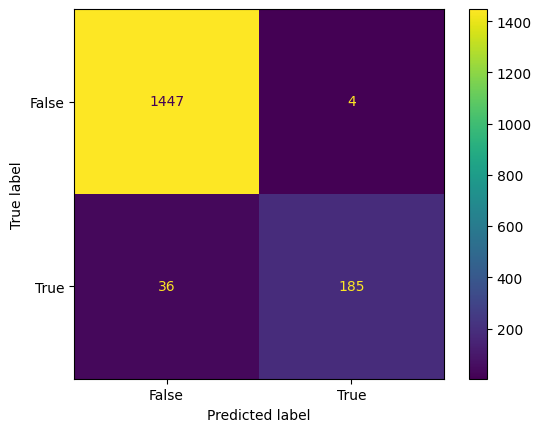

********************
              precision    recall  f1-score   support

       False       0.98      1.00      0.99      1451
        True       0.98      0.84      0.90       221

    accuracy                           0.98      1672
   macro avg       0.98      0.92      0.94      1672
weighted avg       0.98      0.98      0.98      1672



In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)
plt.show()

print('*'*20)

# Classification Report
print(classification_report(y_test, test_prediction))

In [31]:
# import pickle
# filename = 'vectorizer.pkl'
# pickle.dump(cv, open(filename, 'wb'))


import pickle
filename = 'vectorizer.pkl'
pickle.dump(cv, open(filename, 'wb'))

In [32]:
filename = 'rfc.pkl'
pickle.dump(rfc, open(filename, 'wb'))

In [33]:
# input prediction 

In [34]:
import re
import pickle
from nltk.stem import WordNetLemmatizer
import nltk

# Download required NLTK data (run once)
nltk.download('wordnet')

# Initialize lemmatizer
wo = WordNetLemmatizer()

# =========================
# PREPROCESS FUNCTION
# =========================
def preprocess(data):
    a = re.sub('[^a-zA-Z]', ' ', data)
    a = a.lower()
    a = a.split()
    a = [wo.lemmatize(word) for word in a]
    a = ' '.join(a)
    return a

# =========================
# LOAD MODEL & VECTORIZER
# =========================
print("Loading model and vectorizer...")

with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

with open('rfc.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model loaded successfully ✅")

# =========================
# USER INPUT
# =========================
# (For Notebook use direct string instead of input)

try:
    user_input = input("Enter Your Message: ")
except:
    user_input = "Congratulations! You won a free prize 🎉"

print("-------------------------------")

# =========================
# PREPROCESS INPUT
# =========================
processed_text = preprocess(user_input)

# =========================
# TRANSFORM USING TF-IDF
# =========================
vector_input = vectorizer.transform([processed_text])

# =========================
# PREDICTION
# =========================
prediction = model.predict(vector_input)

# =========================
# OUTPUT RESULT
# =========================
if prediction[0] == 0:
    print("Result: Ham (Normal Message)")
else:
    print("Result: Spam 🚨")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91756\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loading model and vectorizer...
Model loaded successfully ✅
-------------------------------
Result: Ham (Normal Message)


In [35]:
import re
from nltk.stem import WordNetLemmatizer
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

wo = WordNetLemmatizer()

def preprocess(data):
    a = re.sub('[^a-zA-Z]',' ',data)
    a = a.lower()
    a = a.split()
    a = [wo.lemmatize(word) for word in a ]
    a = ' '.join(a)  
    return a

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rfc.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")

a = preprocess(strr)
example_counts = vectorizer.transform([a])
prediction = mnb.predict(example_counts)

if prediction[0] == 0:
    print('Ham')
elif prediction[0] == 1:
    print('Spam')


-------------------------------
Ham


In [36]:
import re
from nltk.stem import WordNetLemmatizer
import pickle
import nltk

# download once (safe)
nltk.download('wordnet')

wo = WordNetLemmatizer()

def preprocess(data):
    a = re.sub('[^a-zA-Z]', ' ', data)
    a = a.lower()
    a = a.split()
    a = [wo.lemmatize(word) for word in a]
    a = ' '.join(a)
    return a

# Load vectorizer and model (SAFE LOADING)
print("Loading...")

with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

with open('rfc.pkl', 'rb') as f:
    mnb = pickle.load(f)

print("Loaded ✅")

# INPUT (this is where it was getting stuck sometimes)
try:
    strr = input('Enter Your Message: ')
except:
    strr = "You won free money"

print("-------------------------------")

# PROCESS
a = preprocess(strr)

# TRANSFORM
example_counts = vectorizer.transform([a])

# PREDICT
prediction = mnb.predict(example_counts)

# OUTPUT
if prediction[0] == 0:
    print('Ham')
elif prediction[0] == 1:
    print('Spam')

Loading...
Loaded ✅


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91756\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


-------------------------------
Ham


0.9778708133971292
0.9838461538461538
********************
0.9728999847034482
********************
[[1448    3]
 [  34  187]]
********************


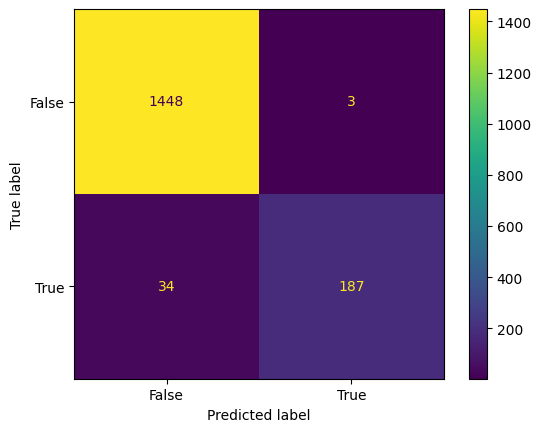

********************
              precision    recall  f1-score   support

       False       0.98      1.00      0.99      1451
        True       0.98      0.85      0.91       221

    accuracy                           0.98      1672
   macro avg       0.98      0.92      0.95      1672
weighted avg       0.98      0.98      0.98      1672



In [37]:
# =========================
# IMPORT MODEL
# =========================
from xgboost import XGBClassifier

# model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# =========================
# TRAIN MODEL
# =========================
xgb_model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
train_prediction = xgb_model.predict(X_train)
test_prediction = xgb_model.predict(X_test)

# =========================
# EVALUATION
# =========================
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, test_prediction))
print(accuracy_score(y_train, train_prediction))

print('*'*20)

# =========================
# CROSS VALIDATION
# =========================
from sklearn.model_selection import cross_val_score

score = cross_val_score(xgb_model, X, y, cv=5)
print(score.mean())

print('*'*20)

# =========================
# CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, test_prediction))

print('*'*20)

# =========================
# PLOT CONFUSION MATRIX
# =========================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)
plt.show()

print('*'*20)

# =========================
# CLASSIFICATION REPORT
# =========================
from sklearn.metrics import classification_report

print(classification_report(y_test, test_prediction))

In [38]:
import pickle

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("Model saved successfully ✅")

Model saved successfully ✅
